# Project: Supermarket Loyalty

International Essentials is an international supermarket chain.

Shoppers at their supermarkets can sign up for a loyalty program that provides rewards each year to customers based on their spending. The more you spend the bigger the rewards. 

The supermarket would like to be able to predict the likely amount customers in the program will spend, so they can estimate the cost of the rewards. 

This will help them to predict the likely profit at the end of the year.

## Data

The dataset contains records of customers for their last full year of the loyalty program.

| Column Name | Criteria                                                |
|-------------|---------------------------------------------------------|
|customer_id | Unique identifier for the customer. </br>Missing values are not possible due to the database structure. |
|spend | Continuous. </br>The total spend of the customer in their last full year. This can be any positive value to two decimal places. </br>Missing values should be replaced with 0. |
|first_month | Continuous. </br>The amount spent by the customer in their first month of the year. This can be any positive value, rounded to two decimal places. </br>Missing values should be replaced with 0. |
| items_in_first_month | Discrete. </br>The number of items purchased in the first month. Any integer value greater than or equal to zero. </br>Missing values should be replaced by 0. |  
| region | Nominal. </br>The geographic region that the customer is based in. One of four values Americas, Asia/Pacific, Europe, Middle East/Africa. </br>Missing values should be replaced with "Unknown". |
| loyalty_years | Oridinal. </br>The number of years the customer has been a part of the loyalty program. One of five ordered categories, '0-1', '1-3', '3-5', '5-10', '10+'. </br>Missing values should be replaced with '0-1'.|
| joining_month | Nominal. </br>The month the customer joined the loyalty program. One of 12 values "Jan", "Feb", "Mar", "Apr", etc. </br>Missing values should be replaced with "N/A".|
| promotion | Nominal. </br>Did the customer join the loyalty program as part of a promotion? Either 'True' or 'False'. </br>Missing values should be replaced with 'False'.|

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme()

In [25]:
df = pd.read_csv('loyalty.csv')
clean_data = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           1246 non-null   int64  
 1   spend                 1246 non-null   float64
 2   first_month           1246 non-null   object 
 3   items_in_first_month  1246 non-null   int64  
 4   region                1246 non-null   object 
 5   loyalty_years         1246 non-null   object 
 6   joining_month         1121 non-null   object 
 7   promotion             1246 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 78.0+ KB


In [26]:
df.head()

,customer_id,spend,first_month,items_in_first_month,region,loyalty_years,joining_month,promotion
0,1,132.68,15.3,5,Asia/Pacific,5-10,Nov,No
1,2,106.45,16.2,14,Asia/Pacific,0-1,Feb,Yes
2,3,123.16,25.26,7,Middle East/Africa,10+,Dec,Yes
3,4,130.60,24.74,8,Middle East/Africa,3-5,Apr,No
4,5,130.41,25.59,8,Middle East/Africa,3-5,Apr,Yes


## Data Cleaning
To match the criteria set above for easier analysis, perform data cleaning as requested.

In [27]:
# Replace missing values

clean_data['first_month'] = clean_data['first_month'].replace('.','0')
clean_data['joining_month'] = clean_data['joining_month'].fillna('N/A')

In [28]:
# Set promotion data as boolean values

clean_data['promotion'] = clean_data['promotion'].str.capitalize()
clean_data['promotion'] = clean_data['promotion'] == 'Yes'

In [29]:
# Convert data into category 

clean_data[['region', 'loyalty_years', 'joining_month']] = clean_data[['region', 'loyalty_years', 'joining_month']].astype('category')

In [30]:
# Set order of loyalty_years data

clean_data['loyalty_years'] = clean_data['loyalty_years'].cat.set_categories(new_categories = ['0-1','1-3','3-5','5-10','10+'], ordered = True)

In [31]:
# Convert data to numerical values rounded to 2 decimals

clean_data[['spend', 'first_month']] = clean_data[['spend', 'first_month']].astype('float64').round(2)

In [32]:
# Check data structure again.

clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   customer_id           1246 non-null   int64   
 1   spend                 1246 non-null   float64 
 2   first_month           1246 non-null   float64 
 3   items_in_first_month  1246 non-null   int64   
 4   region                1246 non-null   category
 5   loyalty_years         1246 non-null   category
 6   joining_month         1246 non-null   category
 7   promotion             1246 non-null   bool    
dtypes: bool(1), category(3), float64(2), int64(2)
memory usage: 45.0 KB


In [33]:
clean_data.head()

,customer_id,spend,first_month,items_in_first_month,region,loyalty_years,joining_month,promotion
0,1,132.68,15.30,5,Asia/Pacific,5-10,Nov,False
1,2,106.45,16.20,14,Asia/Pacific,0-1,Feb,True
2,3,123.16,25.26,7,Middle East/Africa,10+,Dec,True
3,4,130.60,24.74,8,Middle East/Africa,3-5,Apr,False
4,5,130.41,25.59,8,Middle East/Africa,3-5,Apr,True


## Analysing Customer's Spending

### Customer Spending

We now analyze the relationship between customers spending and other values.

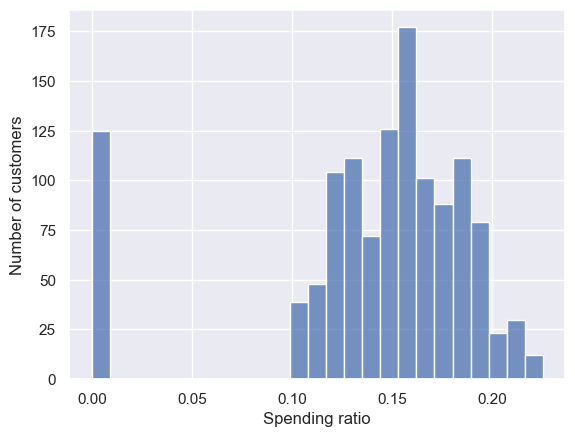

The minimum spend ratio is 0.1, maximum spend ratio is 0.23, and mean value is 0.16


In [34]:
clean_data['spend_ratio'] = clean_data['first_month']/clean_data['spend']

sns.histplot(data = clean_data, x = 'spend_ratio')

plt.xlabel('Spending ratio')
plt.ylabel('Number of customers')
plt.show()

ratio_df = clean_data[clean_data['spend_ratio'] != 0]
min, max, mean = round(ratio_df['spend_ratio'].min(), 2), round(ratio_df['spend_ratio'].max(), 2), round(ratio_df['spend_ratio'].mean(), 2)
print(f'The minimum spend ratio is {min}, maximum spend ratio is {max}, and mean value is {mean}' )

No huge difference were observed between spending on the first month and total spending for a full year.

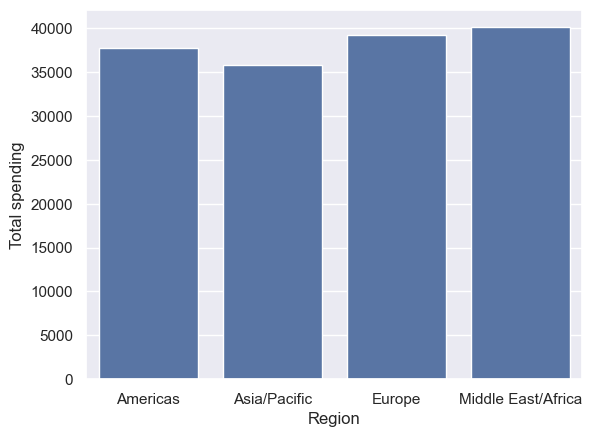

In [35]:
# Total spending vs region

sns.barplot(data = clean_data , x = 'region', y = 'spend' , estimator = 'sum', errorbar = None)

plt.xlabel('Region')
plt.ylabel('Total spending')
plt.show()

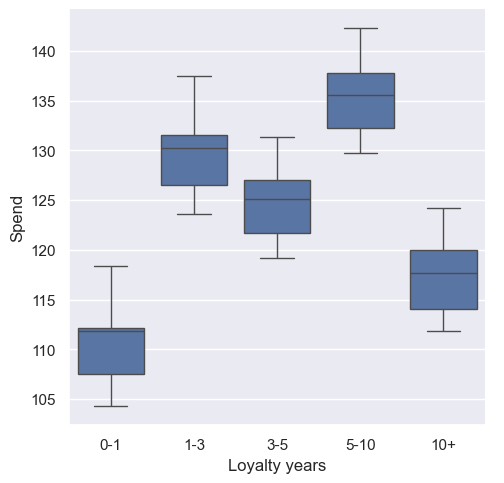

In [36]:
# Spend vs loyalty_years

sns.catplot(data = clean_data, x = 'loyalty_years', y = 'spend', kind = 'box')

plt.xlabel('Loyalty years')
plt.ylabel('Spend')
plt.show()

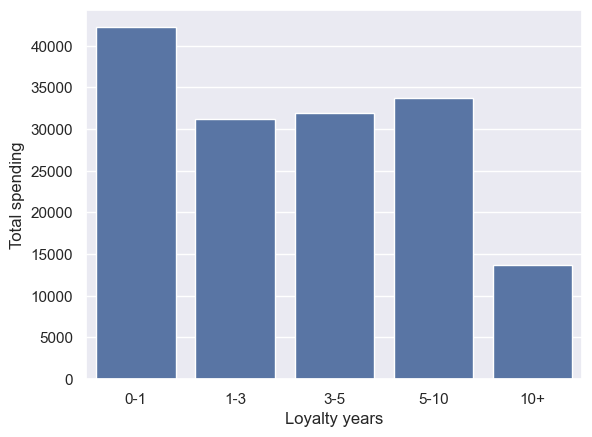

In [37]:
# Total spending vs loyalty_years

sns.barplot(data = clean_data, x = 'loyalty_years', y = 'spend', estimator = 'sum', errorbar = None)

plt.xlabel('Loyalty years')
plt.ylabel('Total spending')
plt.show()

It appears that the number of years in the loyalty scheme is the biggest driver of spend. Customers with at least one year in loyalty program are the highest in number and total spending compared to other categories. The supermarket could suggest introducing reward scheme within the loyalty program for maintaining its membership and increasing advertisement of the loyalty program. 

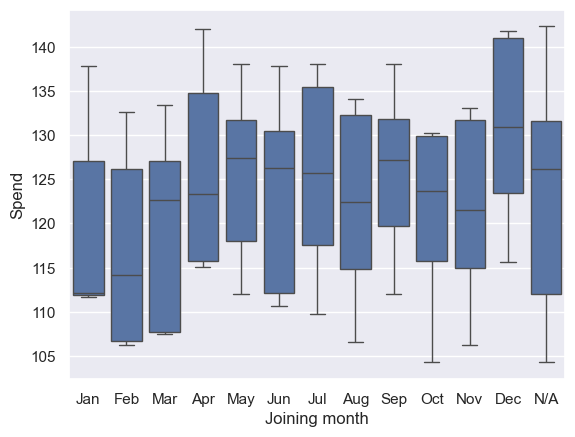

In [38]:
# Spend vs joining_month

order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'N/A']
sns.boxplot(data = clean_data, x = 'joining_month', y = 'spend', order = order)

plt.xlabel('Joining month')
plt.ylabel('Spend')
plt.show()

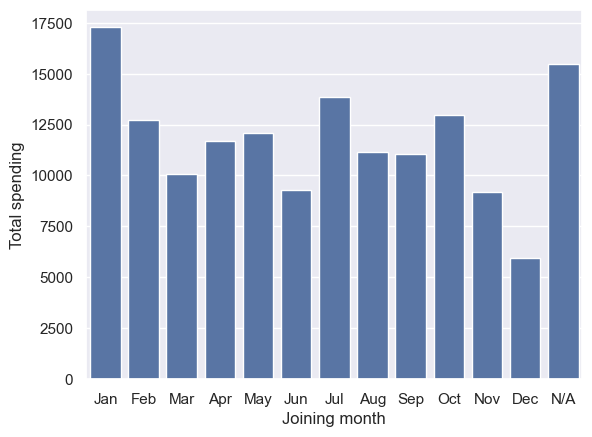

In [39]:
# Total spending vs joining_month

sns.barplot(data = clean_data, x = 'joining_month', y = 'spend', order = order, estimator = 'sum', errorbar = None)

plt.xlabel('Joining month')
plt.ylabel('Total spending')
plt.show()

Distributions of customer's spending alongide joining months appear to flucturate with no patterns, while customers are more likely to spend more upon joining on January.

### Is promotion effective?

The supermarket is interested to know whether customers who joined loyalty scheme as part of promotion will spend more. An hypotheis testing is made where the starting assumption is that the mean spending of customers is the same regardless of the promotion, and the alternative assumption is the opposite.

In [40]:
group = clean_data.groupby('promotion')['spend'].mean()
no_promotion_mean = round(group.loc[False], 2)
promotion_mean = round(group.loc[True], 2)
print(f'Mean spending for customers with no promotion is {no_promotion_mean}')
print(f'Mean spending for customers with promotion is {promotion_mean}')

Mean spending for customers with no promotion is 123.13
Mean spending for customers with promotion is 122.12


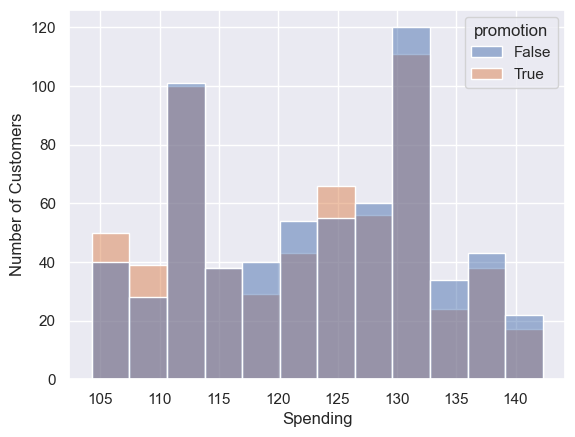

In [41]:
# Check whether customer's spending follows normal distributions

sns.histplot(data = clean_data, x = 'spend', hue = 'promotion')

plt.xlabel('Spending')
plt.ylabel('Number of Customers')
plt.show()

In [42]:
# Since the distribution appears non-normal, use the Mann-Whitney U rank test 

import scipy

alpha = 0.01

x = clean_data[clean_data['promotion'] == False]['spend']
y = clean_data[clean_data['promotion'] == True]['spend']

_, p_val = scipy.stats.mannwhitneyu(x, y, alternative='two-sided')

print(f'P-value is {p_val}')

if p_val > alpha:
    print('Fail to reject starting assumption. No strong evidence of difference.')
else:
    print('Reject assumption. Significant difference found.')

P-value is 0.06742320369217163
Fail to reject starting assumption. No strong evidence of difference.


This concludes that promotion made neither positive nor negative impact on customer's spending.

## Predicting Customer's Spending

### Baseline Model: Linear Regression
A simple linear regression model is developed without hyperparameter tuning as a baseline model. Performance is measured by calculating coefficient of determination $R^2$, with $R^2 = 1$ being the best performance and $R^2 = 0$ being the worst.

In [43]:
from sklearn.preprocessing import OrdinalEncoder

# Encoding ordinal feature for machine learning 

new_categories=[['0-1','1-3','3-5','5-10','10+']]
oe = OrdinalEncoder(categories=new_categories)

clean_data['loyalty_years_encoded'] = oe.fit_transform(clean_data[['loyalty_years']])

In [44]:
# Convert categorical variables into dummy variables

data_ML=pd.get_dummies(clean_data, columns=['region','joining_month','promotion'])
data_ML.columns

Index(['customer_id', 'spend', 'first_month', 'items_in_first_month',
       'loyalty_years', 'spend_ratio', 'loyalty_years_encoded',
       'region_Americas', 'region_Asia/Pacific', 'region_Europe',
       'region_Middle East/Africa', 'joining_month_Apr', 'joining_month_Aug',
       'joining_month_Dec', 'joining_month_Feb', 'joining_month_Jan',
       'joining_month_Jul', 'joining_month_Jun', 'joining_month_Mar',
       'joining_month_May', 'joining_month_N/A', 'joining_month_Nov',
       'joining_month_Oct', 'joining_month_Sep', 'promotion_False',
       'promotion_True'],
      dtype='object')

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Split data into independent and dependent variables

X = data_ML.drop(columns=['customer_id','spend','loyalty_years'])
y = data_ML['spend']

# Apply linear regression model then evaluate performance

lr = LinearRegression()
linear_r2 = cross_val_score(lr, X, y, cv = 5, scoring = 'r2')
print(linear_r2)
print(f'Mean R2 score is {linear_r2.mean()}')

[0.9000335  0.89249222 0.90284429 0.88980377 0.89729223]
Mean R2 score is 0.8964932020095461


Recall from the previous analysis, there are several uncorrelated features which are uninformative in training our machine learning model. To solve these issues, we use a more complex model where feature selections are part of the process and apply cross-validation with hyperparemeter tuning.

### Final Model: Random Forest Regression
A more complex regression model is developed with hyperparameter tuning as a final model for actual prediction.

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Add feature standardization alongside ramdom forest model in a pipeline

pipeline = Pipeline(steps = [ ('scaler', StandardScaler()), ('regressor', RandomForestRegressor()) ] )

# Set hyperparameters to be tuned

param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 3, 5]
}

# Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 44)

# Perform grid search cross-validation to obtain optimal hyperpameters

grid_search = GridSearchCV(pipeline, param_grid, cv = 5, scoring = 'r2')

grid_search.fit(X_train, y_train)

# Evaluate final model performance

print("Best parameters found: ", grid_search.best_params_)
print("Best score found: ", grid_search.best_score_)
test_score = grid_search.score(X_test, y_test)
print(f'Final Score: {test_score}')

Best parameters found:  {'regressor__max_depth': 20, 'regressor__min_samples_split': 3, 'regressor__n_estimators': 100}
Best score found:  0.9914747712892513
Final Score: 0.9925782916887961


With a final score of 0.99, our final model is ready for predicting customer's spending for a year. To use our final model, use the following code:

```
y_pred = grid_score.predict(df)
```

where df is the dataset containing records of customers for their last full year of the loyalty program, and y_pred is the predicted customer's spending.

## Conclusion

We manage to develope a model predicting customer's spending as part of loyalty scheme. From the analysis of the dataset:

- Customers with 0-1 year in loyalty program are the highest in total spending, while customers with 5-10 yeats in loyalty program spend more on average.
- Promotion made neither positive nor negative effect on customer's spending.